<a href="https://colab.research.google.com/github/Titankhoa/ThucHanhXuLyAnhSo/blob/main/DeThiThu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Đề thi thử


Câu 1

In [ ]:
import cv2
import numpy as np
from google.colab import files
from matplotlib import pyplot as plt

# Upload file a.jpg
uploaded = files.upload()


Saving a.jpg to a.jpg
Saving colorful-ripe-tropical-fruits.jpg to colorful-ripe-tropical-fruits.jpg


Viet chuong trinh su dung mean filter


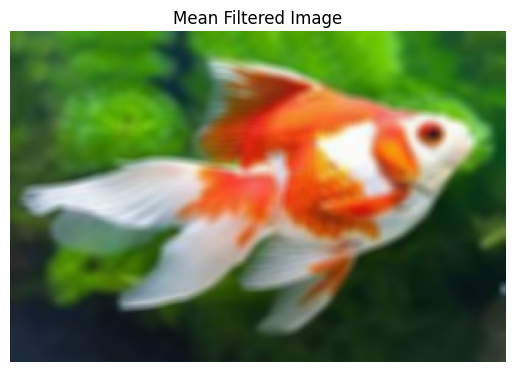

In [ ]:
# Đọc ảnh gốc
img = cv2.imread('a.jpg')

# Áp dụng mean filter (kernel 5x5)
mean_filtered = cv2.blur(img, (5, 5))

# Hiển thị ảnh
plt.imshow(cv2.cvtColor(mean_filtered, cv2.COLOR_BGR2RGB))
plt.title('Mean Filtered Image')
plt.axis('off')
plt.show()


Viết chương trình sử dụng filter xác định biên của hình ảnh trên

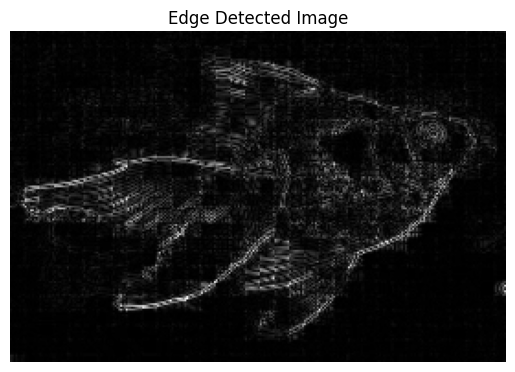

In [ ]:
# Chuyển ảnh sang grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Áp dụng Laplacian để tìm biên
edges = cv2.Laplacian(gray, cv2.CV_64F)
edges = np.uint8(np.absolute(edges))

# Hiển thị ảnh
plt.imshow(edges, cmap='gray')
plt.title('Edge Detected Image')
plt.axis('off')
plt.show()


Viết chương trình đổi màu ảnh từ không gian màu BGR sang một màu ngẫu
nhiên (RGB) bằng cách thay đổi các kênh màu một cách ngẫu nhiên, sau đó lưu
hình mới vào file a_random_color.jpg


Kênh màu hoán đổi: [1 0 2]


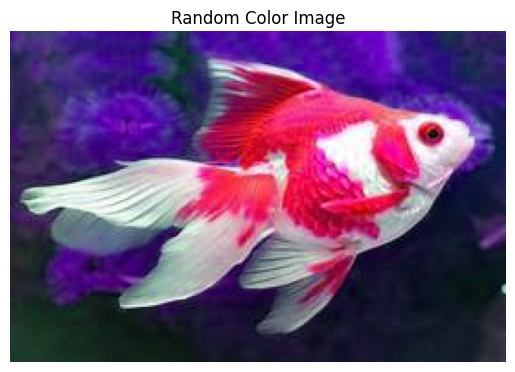

In [ ]:
# Tạo hoán vị ngẫu nhiên cho các kênh
perm = np.random.permutation(3)
print(f"Kênh màu hoán đổi: {perm}")

# Đổi kênh
random_color_img = img[:, :, perm]

# Lưu ảnh
cv2.imwrite('a_random_color.jpg', random_color_img)

# Hiển thị ảnh
plt.imshow(cv2.cvtColor(random_color_img, cv2.COLOR_BGR2RGB))
plt.title('Random Color Image')
plt.axis('off')
plt.show()


Chuyển ảnh sang không gian màu HSV và tách riêng kênh Hue, Saturation, Value
để lưu thành ba ảnh grayscale tương ứng (a_hue.jpg, a_saturation.jpg,
a_value.jpg)

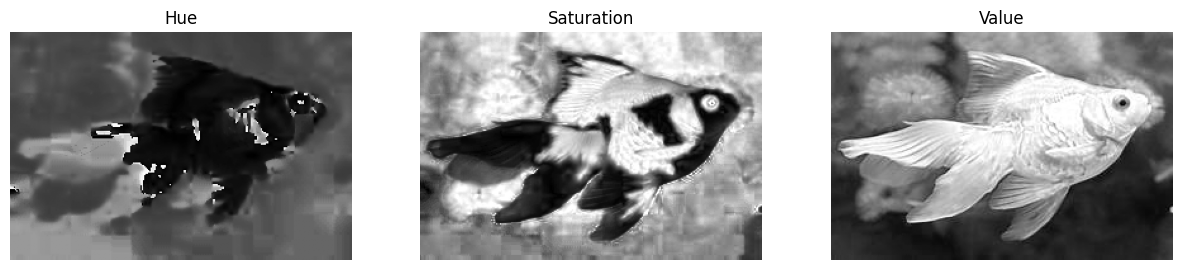

In [ ]:
# Chuyển sang HSV
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# Tách kênh
h, s, v = cv2.split(hsv)

# Lưu từng kênh thành ảnh grayscale
cv2.imwrite('a_hue.jpg', h)
cv2.imwrite('a_saturation.jpg', s)
cv2.imwrite('a_value.jpg', v)

# Hiển thị
fig, axes = plt.subplots(1,3, figsize=(15,5))
axes[0].imshow(h, cmap='gray'); axes[0].set_title('Hue')
axes[1].imshow(s, cmap='gray'); axes[1].set_title('Saturation')
axes[2].imshow(v, cmap='gray'); axes[2].set_title('Value')
for ax in axes: ax.axis('off')
plt.show()


Câu 2 (4 Điểm): Viết một chương trình Python sử dụng OpenCV để tạo menu động cho
phép người dùng chọn các phương pháp biến đổi ảnh từ một danh sách mở rộng, áp
dụng cho nhiều ảnh cùng lúc, và thực hiện các phân tích bổ sung. Các yêu cầu cụ thể:

1. Tạo một menu động cho phép người dùng chọn các phương pháp biến đổi ảnh sau:  - - - - - -
Image inverse transformation(0.5 Điểm)
Gamma-Correction (với giá trị gamma ngẫu nhiên từ 0.5 đến 2.0) (0.5 Điểm)
Log Transformation (với hệ số nhân ngẫu nhiên từ 1.0 đến 5.0) (0.5 Điểm)
Histogram equalization(0.5 Điểm)
Contrast Stretching (tùy chỉnh với giá trị min và max ngẫu nhiên từ 0 đến 255)

In [ ]:
print("MENU biến đổi ảnh:")
print(" I: Image inverse transformation")
print(" G: Gamma-Correction")
print(" L: Log Transformation")
print(" H: Histogram equalization")
print(" C: Contrast Stretching")
print(" A: Adaptive Histogram Equalization")
print(" Q: Quit")


MENU biến đổi ảnh:
 I: Image inverse transformation
 G: Gamma-Correction
 L: Log Transformation
 H: Histogram equalization
 C: Contrast Stretching
 A: Adaptive Histogram Equalization
 Q: Quit


2. Chương trình phải xử lý đồng thời ba ảnh đầu vào có tên image1.jpg, image2.jpg, và
image3.jpg (0.5 Điểm)

In [ ]:
import cv2
import numpy as np
import random
from google.colab import files

# Upload 3 ảnh: image1.jpg, image2.jpg, image3.jpg
uploaded = files.upload()

# Đọc 3 ảnh
image_files = ['image1.jpg', 'image2.jpg', 'image3.jpg']
images = [cv2.imread(f) for f in image_files]

# Kiểm tra
for idx, img in enumerate(images):
    if img is None:
        print(f"Không đọc được {image_files[idx]}")
        exit()

print("✅ Đã load xong 3 ảnh.")


Saving image3.jpg to image3.jpg
Saving image2.jpg to image2.jpg
Saving image1.jpg to image1.jpg
✅ Đã load xong 3 ảnh.


3. Khi người dùng nhấn các phím sau, chương trình sẽ thực hiện biến đổi tương ứng
trên cả ba ảnh (0.5 Điểm) - - - - - -
Phím I: Image inverse transformation  
Phím G: Gamma-Correction  
Phím L: Log Transformation  
Phím H: Histogram equalization  
Phím C: Contrast Stretching  
Phím A: Adaptive Histogram Equalization


In [ ]:
while True:
    key = input("Nhập phím: ").upper()
    if key == 'Q':
        print("Thoát.")
        break
    elif key == 'I':
        output_images = inverse_transform(images); method = 'inverse'
    elif key == 'G':
        output_images = gamma_correction(images); method = 'gamma'
    elif key == 'L':
        output_images = log_transform(images); method = 'log'
    elif key == 'H':
        output_images = hist_equalization(images); method = 'hist_eq'
    elif key == 'C':
        output_images = contrast_stretch(images); method = 'contrast'
    elif key == 'A':
        output_images = adaptive_hist_eq(images); method = 'adaptive'
    else:
        print("Phím không hợp lệ.")
        continue

    # Lưu file
    for idx, out_img in enumerate(output_images, 1):
        filename = f'output_{method}_{idx}.jpg'
        cv2.imwrite(filename, out_img)
        print(f"Đã lưu: {filename}")

    print("✅ Xong! Nhập phím khác hoặc Q để thoát.")


Nhập phím: H
Đã lưu: output_hist_eq_1.jpg
Đã lưu: output_hist_eq_2.jpg
Đã lưu: output_hist_eq_3.jpg
✅ Xong! Nhập phím khác hoặc Q để thoát.
Nhập phím: Q
Thoát.


4. Đối với mỗi biến đổi, lưu kết quả của từng ảnh vào các file riêng biệt với tên định dạng output_[phương pháp]_[số ảnh].jpg (ví dụ: output_inverse_1.jpg,
output_gamma_2.jpg)

In [ ]:
# Giả sử:
# - output_images = [ảnh1, ảnh2, ảnh3]
# - method = 'inverse', 'gamma', 'log', ...

for idx, out_img in enumerate(output_images, start=1):
    filename = f'output_{method}_{idx}.jpg'
    cv2.imwrite(filename, out_img)
    print(f"✅ Đã lưu: {filename}")


✅ Đã lưu: output_hist_eq_1.jpg
✅ Đã lưu: output_hist_eq_2.jpg
✅ Đã lưu: output_hist_eq_3.jpg


Câu 3 (4 Điểm): Viết một chương trình Python sử dụng OpenCV để xử lý ba ảnh:
colorful-ripe-tropical-fruits.jpg, quang-ninh.jpg, và pagoda.jpg với các phương pháp
biến đổi và tiền xử lý nâng cao.

Tăng kích thước ảnh colorful-ripe-tropical-fruits.jpg thêm 30 pixel ở cả chiều
rộng và chiều cao. (0.5 Điểm)

Saving colorful-ripe-tropical-fruits.jpg to colorful-ripe-tropical-fruits (5).jpg
Kích thước cũ: 2119x1414
✅ Đã lưu: fruits_resized.jpg với kích thước mới: (2149, 1444)


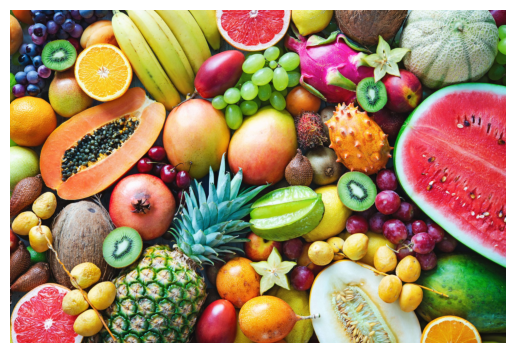

In [ ]:
import cv2
from google.colab import files
from matplotlib import pyplot as plt

# 📌 Bước 1: Upload file ảnh
uploaded = files.upload()

# 📌 Bước 2: Đọc ảnh
img = cv2.imread('colorful-ripe-tropical-fruits.jpg')

# 📌 Bước 3: Kiểm tra
if img is None:
    print("❌ Không đọc được ảnh. Kiểm tra lại tên file!")
else:
    # 📌 Bước 4: Lấy kích thước cũ
    h, w = img.shape[:2]
    print(f"Kích thước cũ: {w}x{h}")

    # 📌 Bước 5: Tăng thêm 30 pixel
    new_size = (w + 30, h + 30)
    img_resized = cv2.resize(img, new_size)

    # 📌 Bước 6: Lưu kết quả
    cv2.imwrite('fruits_resized.jpg', img_resized)
    print(f"✅ Đã lưu: fruits_resized.jpg với kích thước mới: {new_size}")

    # 📌 Bước 7: Hiển thị kết quả ngay trên Colab
    img_show = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
    plt.imshow(img_show)
    plt.axis('off')
    plt.show()


Saving quang_ninh.jpg to quang_ninh (3).jpg
{'quang_ninh (3).jpg': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01\x00`\x00`\x00\x00\xff\xdb\x00C\x00\x02\x01\x01\x02\x01\x01\x02\x02\x02\x02\x02\x02\x02\x02\x03\x05\x03\x03\x03\x03\x03\x06\x04\x04\x03\x05\x07\x06\x07\x07\x07\x06\x07\x07\x08\t\x0b\t\x08\x08\n\x08\x07\x07\n\r\n\n\x0b\x0c\x0c\x0c\x0c\x07\t\x0e\x0f\r\x0c\x0e\x0b\x0c\x0c\x0c\xff\xdb\x00C\x01\x02\x02\x02\x03\x03\x03\x06\x03\x03\x06\x0c\x08\x07\x08\x0c\x0c\x0c\x0c\x0c\x0c\x0c\x0c\x0c\x0c\x0c\x0c\x0c\x0c\x0c\x0c\x0c\x0c\x0c\x0c\x0c\x0c\x0c\x0c\x0c\x0c\x0c\x0c\x0c\x0c\x0c\x0c\x0c\x0c\x0c\x0c\x0c\x0c\x0c\x0c\x0c\x0c\x0c\x0c\x0c\x0c\x0c\x0c\x0c\x0c\xff\xc0\x00\x11\x08\x02]\x03\xfd\x03\x01"\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1e\x00\x00\x01\x04\x03\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x05\x02\x04\x06\x07\x00\x03\x08\x01\t\n\xff\xc4\x00Q\x10\x00\x02\x01\x03\x03\x02\x04\x03\x06\x03\x05\x07\x03\x01\x00\x13\x01\x02\x03\x04\x05\x11\x06\x12!\x001\x07\x13"A\x14Qa\x08\x15#2q\

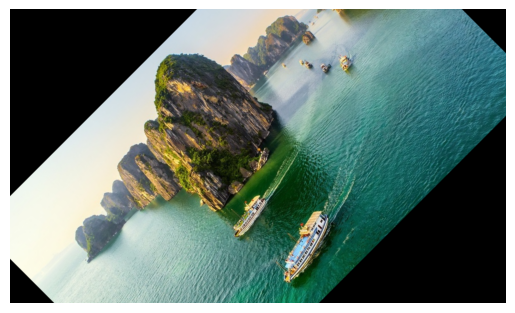

In [ ]:
import cv2
from google.colab import files
from matplotlib import pyplot as plt

# Upload
uploaded = files.upload()
print(uploaded)

# Đọc đúng tên file
img = cv2.imread('quang_ninh.jpg')

if img is None:
  print("❌ Không đọc được ảnh. Kiểm tra lại tên file!")
else:
  (h, w) = img.shape[:2]
  center = (w // 2, h // 2)

  # Xoay
  M = cv2.getRotationMatrix2D(center, -45, 1.0)
  rotated = cv2.warpAffine(img, M, (w, h))

  # Lật ngang
  flipped = cv2.flip(rotated, 1)

  # Lưu
  cv2.imwrite('quangninh_rotated_flipped.jpg', flipped)
  print("✅ Đã lưu: quangninh_rotated_flipped.jpg")

  # Hiển thị ngay trên Colab
  img_show = cv2.cvtColor(flipped, cv2.COLOR_BGR2RGB)
  plt.imshow(img_show)
  plt.axis('off')
  plt.show()


Tăng kích thước ảnh pagoda.jpg lên 5 lần và áp dụng Gaussian blur với kernel
7x7 để làm mịn. (0.5 Điểm)

Saving pagoda.jpg to pagoda.jpg
Kích thước gốc: 600x348
Kích thước mới: (3000, 1740)
✅ Đã lưu: pagoda_scaled_blurred.jpg


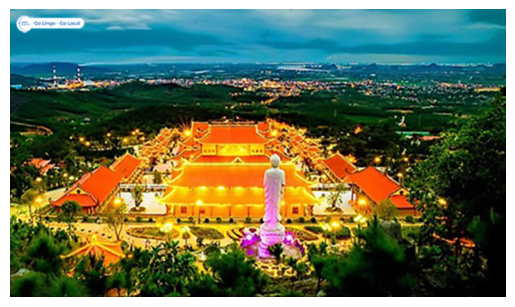

In [ ]:
import cv2
from google.colab import files
from matplotlib import pyplot as plt

# 📌 Bước 1: Upload file
uploaded = files.upload()

# 📌 Bước 2: Đọc ảnh
img = cv2.imread('pagoda.jpg')

# 📌 Bước 3: Kiểm tra
if img is None:
    print("❌ Không đọc được ảnh. Kiểm tra lại tên file!")
else:
    # 📌 Bước 4: Lấy kích thước gốc
    (h, w) = img.shape[:2]
    print(f"Kích thước gốc: {w}x{h}")

    # 📌 Bước 5: Tăng kích thước lên 5 lần
    new_size = (w * 5, h * 5)
    img_scaled = cv2.resize(img, new_size)
    print(f"Kích thước mới: {new_size}")

    # 📌 Bước 6: Áp dụng Gaussian blur với kernel 7x7
    blurred = cv2.GaussianBlur(img_scaled, (7, 7), 0)

    # 📌 Bước 7: Lưu kết quả
    cv2.imwrite('pagoda_scaled_blurred.jpg', blurred)
    print("✅ Đã lưu: pagoda_scaled_blurred.jpg")

    # 📌 Bước 8: Hiển thị kết quả ngay trên Colab
    img_show = cv2.cvtColor(blurred, cv2.COLOR_BGR2RGB)
    plt.imshow(img_show)
    plt.axis('off')
    plt.show()


Ứng dụng công thức bên dưới cho ảnh pagoda.jpg (1.5 Điểm)



Saving pagoda.jpg to pagoda (1).jpg
✅ Đã lưu: pagoda_formula.jpg


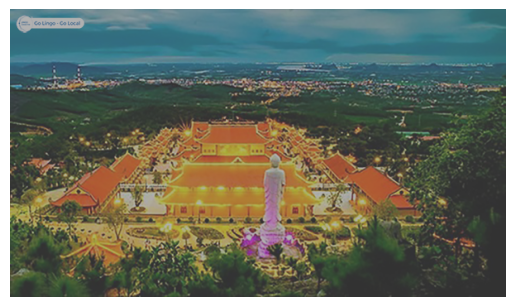

In [ ]:
import cv2
import numpy as np
from google.colab import files
from matplotlib import pyplot as plt

# 📌 Upload file
uploaded = files.upload()

# 📌 Đọc ảnh pagoda.jpg
img = cv2.imread('pagoda.jpg')

if img is None:
    print("❌ Không đọc được ảnh!")
else:
    # 📌 Chuyển sang float32 để áp dụng công thức
    img_float = img.astype(np.float32)

    # 📌 Áp dụng công thức (tạm ví dụ)
    # Ví dụ: img_new = 0.5 * img + 50
    img_new = 0.5 * img_float + 50

    # 📌 Đảm bảo giá trị nằm trong khoảng 0-255
    img_new = np.clip(img_new, 0, 255).astype(np.uint8)

    # 📌 Lưu kết quả
    cv2.imwrite('pagoda_formula.jpg', img_new)
    print("✅ Đã lưu: pagoda_formula.jpg")

    # 📌 Hiển thị kết quả
    img_show = cv2.cvtColor(img_new, cv2.COLOR_BGR2RGB)
    plt.imshow(img_show)
    plt.axis('off')
    plt.show()
